# Import a CAD model

In this tutorial we import a circular waveguide from a STEP file, mesh it,
check the ports the importer found, and compare its S- and Z-parameters with
the closed-form solution for the TE11 mode.

**Prerequisites:** the [Basics](../basics/index.md) tutorials. The STEP file,
`circular_waveguide.step`, ships with the documentation in
`docs/example_models/`.

## 1. Import the geometry

### 1.1 Add the STEP file as a part

`import_geometry` reads a STEP, IGES or BREP file and adds it to the project
as a part, as `create_primitive` did for the waveguide in the basics
tutorials. `unit` is the length unit the file was written in; this file is in
metres. The code converts every file to metres.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="cad_import", base_dir="./simulations", overwrite=True)

geo = proj.import_geometry("../../example_models/circular_waveguide.step",
                           name="guide", unit="m")

✅ Creating new project 'cad_import' at simulations\cad_import



STEP solids found:
  - vacuum

Solid: 'vacuum'
Ports by position along Z: port1, port2


The importer reports what it found: one solid, called `vacuum` in the STEP
file, and two ports, named by position along the guide's axis.

### 1.2 Look at the geometry

In [2]:
# 3D view -- uncomment to open it when you run the notebook:
# geo.show()

A cylinder. `get_bounding_box` gives its size in metres:

In [3]:
lo, hi = geo.get_bounding_box()
print("from", [round(v, 3) for v in lo], "to", [round(v, 3) for v in hi])

from [-0.15, -0.15, -0.0] to [0.15, 0.15, 0.3]


The cylinder runs along z from 0 to 0.3 m, and its radius is 0.15 m.

## 2. Mesh it

### 2.1 Generate the mesh

`maxh` is in metres, like every length. At the top of our band, 1.5 GHz, the
free-space wavelength is 0.2 m; `maxh=0.04` puts about five elements in a
wavelength, which is enough with the default third-order elements.

In [4]:
proj.generate_mesh(maxh=0.04)
print(f"{proj.mesh.ne} tetrahedra")

1362 tetrahedra


If a `maxh` is larger than the model, the code warns that it will not constrain
the mesh. That warning almost always means a length was given in millimetres.

### 2.2 Look at the mesh

In [5]:
# 3D view -- uncomment to open it when you run the notebook:
# proj.geo.show("mesh")

The curved wall is meshed with curved elements, so the circle stays round even
with large elements.

## 3. Check the ports

The importer took the two flat end faces as ports. The port map shows how the
solver sees them:

In [6]:
proj.fds.print_port_map()


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 1362
 idx  port      geometry    dims [mm]                 carries       role
   0  port1     circular    R=150.00                  TE/TM         external
   1  port2     circular    R=150.00                  TE/TM         external

nportmodes accepts:
  int   nportmodes=1
  list  nportmodes=[1, 1]   (one entry per port, this order)
  dict  nportmodes={'port1': 1, 'port2': 1, 'default': 1}


Both ports are recognised as `circular`, with a radius of 150 mm. For a
circular cross-section the port modes are known in closed form.

## 4. Solve and compare

### 4.1 Run the sweep

The lowest mode of a circular guide, TE11, has its cutoff at
$f_c = 1.841\,c_0 / (2\pi r) \approx 0.586$ GHz. We sweep from 0.3 to
1.5 GHz and keep one mode per port.

In [7]:
res = proj.fds.solve(fmin=0.3, fmax=1.5, nsamples=41)

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=12.2745, sigma=+1
	port2 mode 0: TE_11 (cos), kc=12.2745, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.3000 - 1.5000 GHz, 41 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 44.12s (total iteration steps: 6333)


The port log names the mode: `TE_11`.

### 4.2 Build the exact solution

`CWGAnalytical` is the circular counterpart of `RWGAnalytical`. It takes the
radius and length in metres and the frequency range in GHz.

In [8]:
import matplotlib.pyplot as plt

from cavsim3d.analytical import CWGAnalytical

ana = CWGAnalytical(radius=0.15, length=0.3, freq_range=(0.3, 1.5))
print(f"TE11 cutoff: {ana.cutoff_frequency_TE(1, 1):.4f} GHz")

TE11 cutoff: 0.5857 GHz


### 4.3 Compare the S-parameters

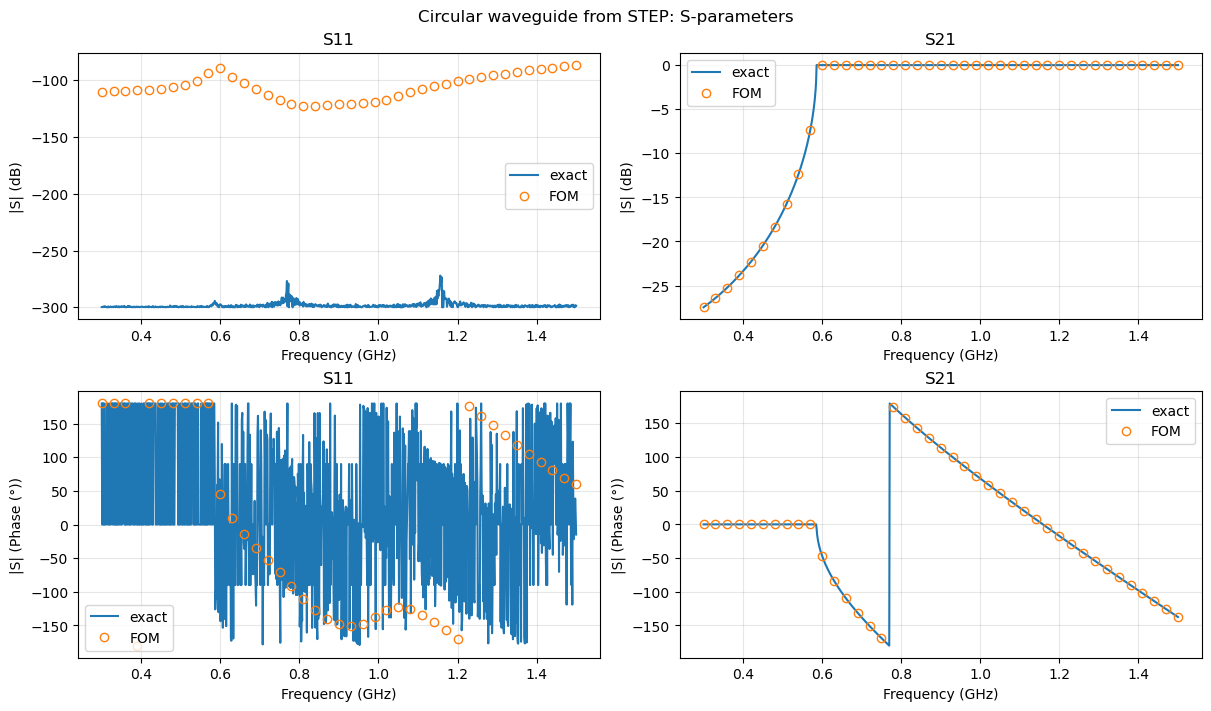

In [9]:
fom = proj.fds.fom

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_s([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_s([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none", title=f"S{ij}")
fig.suptitle("Circular waveguide from STEP: S-parameters")
plt.show()

$S_{21}$ matches the exact curve through the cutoff and above it. As for the
rectangular guide, the exact $S_{11}$ of a uniform guide is zero, so its
panels show numerical noise only.

### 4.4 Compare the Z-parameters

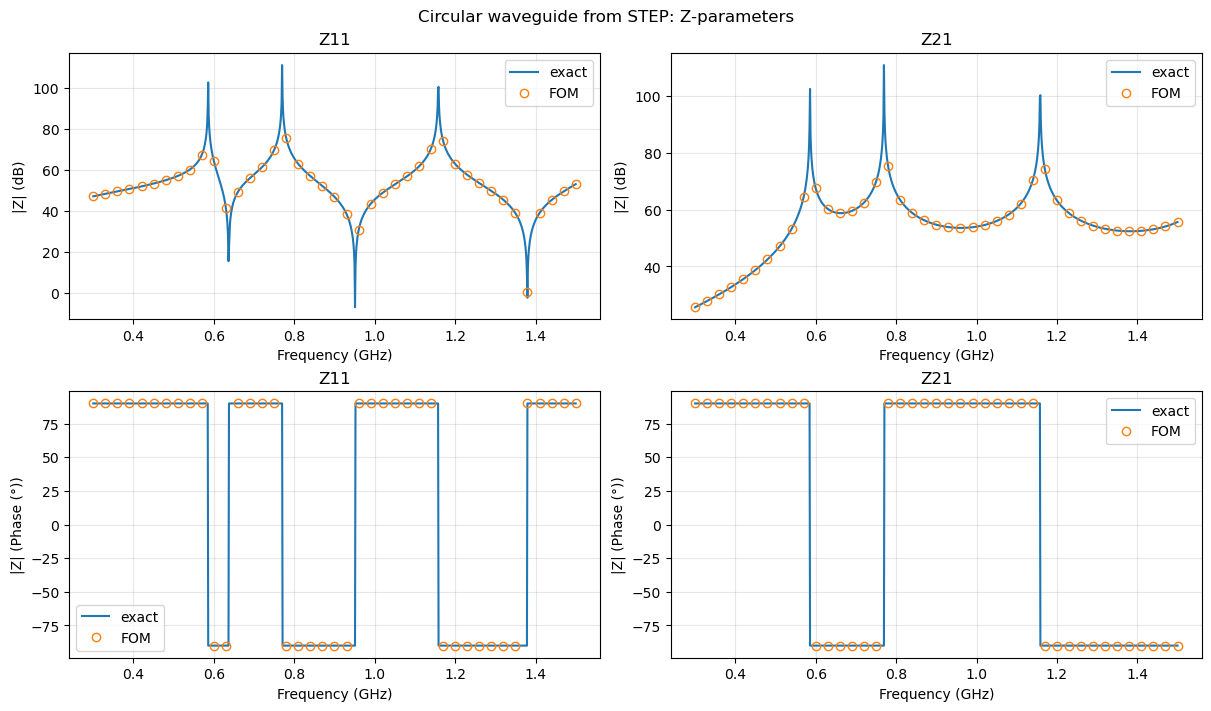

In [10]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_z([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_z([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none", title=f"Z{ij}")
fig.suptitle("Circular waveguide from STEP: Z-parameters")
plt.show()

The impedance peaks are the resonances of the 0.3 m section, as in the
rectangular guide. The FOM samples follow the exact curves.

### 4.5 Measure the difference

In [11]:
import numpy as np

f = res["frequencies"]
S21_exact = ana.s_parameters(f / 1e9)["S21"]
err = np.abs(res["S"][:, 1, 0] - S21_exact)
above = f > 0.65e9                       # clear of the cutoff
print(f"median |S21 - exact| above 0.65 GHz: {np.median(err[above]):.1e}")

median |S21 - exact| above 0.65 GHz: 1.9e-05


A small difference, of the same kind as for the rectangular guide: the
discretisation error of the mesh and the curved wall.

## What we did

We imported a circular waveguide from a STEP file, looked at it and its mesh,
confirmed that both end faces became circular ports, and matched its
S- and Z-parameters to the exact TE11 solution.

**Next:** [Cut a model into domains](splitting_cad.ipynb) splits this guide
into sections that are solved separately and joined again.

**Related:** [How to import a CAD file](../../how-to/import_cad.md) covers
millimetre files, IGES, assigning ports by hand, and naming solids.